In [9]:
# %load_ext autoreload
# %autoreload 2

In [10]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl

from koala import example_graphs as eg
from koala.lattice import Lattice
from dimer_models.lattice_generation import bipartite_squarefull

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

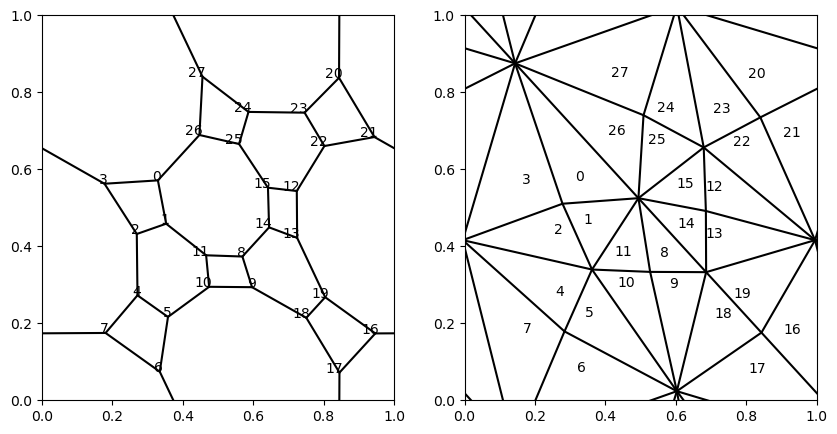

In [11]:
ns = 30

lattice = gu.com_relaxation(bipartite_squarefull(ns, ensure_true_bipartite=True))
dual = gu.make_dual(lattice, reg_steps=0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
pl.plot_edges(lattice, ax=ax[0])
pl.plot_edges(dual, ax=ax[1])
pl.plot_vertex_indices(lattice, ax=ax[1])
pl.plot_vertex_indices(lattice, ax=ax[0])

In [12]:
from collections import Counter


def c1_plus(lattice: Lattice, vertices: np.ndarray):

    assert len(vertices) == 3, "This only words for three adjacent vertices"

    # check that the vertices are adjacent to one another
    adjacent_verts = np.concatenate(
        [lattice.vertices.adjacent_vertices[x] for x in vertices]
    )
    neighbour_counts = np.array(list(Counter(adjacent_verts).items())).T
    assert (
        np.sum(neighbour_counts[1] == 2) == 1
    ), "The vertices have to be consecutive around a plaquette that is not a square"

    central_vertex = neighbour_counts[0, np.where(neighbour_counts[1] == 2)[0]][0]
    adjoint_vertices = vertices[vertices != central_vertex]

    e1 = lattice.vertices.adjacent_edges[central_vertex]

    print(e1)

    return adjoint_vertices


c1_plus(lattice, np.array([8, 13, 9]))
# c1_plus(lattice, np.array([8, 11, 9]))

[27  1 28]


array([ 8, 13,  9])